# 2D Spectral Maxwell Propagation Test

Pipeline:
1. Read a 2D NetCDF field file (`Ex`, `Ey`, `Bz`)
2. Plot the initial `Bz`
3. Apply an arbitrary mask (smoothed with `smooth_mask`) to select a region of interest
4. Feed masked fields into `Spectral_Maxwell_Solver_2D` and propagate
5. Plot `Ex` and `Bz` at each time step

In [2]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336')
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/EM_analyzer')

import os
import numpy as np
import scipy.constants as C
import matplotlib
#matplotlib.use('Agg')          # non-interactive backend for saving PNGs
import matplotlib.pyplot as plt

import jax
jax.config.update('jax_num_cpu_devices', 6)   # must come before importing Normal_variable_method
jax.config.update('jax_enable_x64', True)
jax.config.update('jax_platform_name', 'cpu')
import jax.numpy as jnp

In [3]:
from EM_analyzer.read_write import read_nc
from EM_analyzer.pretreat_fields import smooth_mask
from EM_analyzer.Spectral_Maxwell.Normal_variable_method import Spectral_Maxwell_Solver_2D
from EM_analyzer.plot.plot_2D import plot_2D_field

6
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5)]


## Parameters

In [4]:
# ── paths ────────────────────────────────────────────────────────────────────
nc_file     = 'fields0001_250cpl_reflection_clip.nc'          # ← change to your .nc file path
working_dir = '/scratch/gpfs/MIKHAILOVA/zl8336/Curved_surface/a0=20/2D/K=-0.005,D=0.02,L=0.00'
os.makedirs(working_dir, exist_ok=True)

# ── laser normalization ───────────────────────────────────────────────────────
laser_lambda = 0.8e-6            # m
laser_omega0 = 2 * np.pi * C.speed_of_light / laser_lambda
laser_Ec     = (C.m_e * laser_omega0 / C.elementary_charge) * C.speed_of_light  # V/m
laser_Bc     = C.m_e * laser_omega0 / C.elementary_charge                       # T
laser_period = laser_lambda / C.speed_of_light
laser_a0     = 20.0               # expected peak a0 for colorbar scaling

# ── propagation times ─────────────────────────────────────────────────────────
t_start  = -5 * laser_period
t_end    =  5 * laser_period
n_steps  = 11

# ── mask smoothing ────────────────────────────────────────────────────────────
mask_edge_length = 20            # cells for Tukey taper at mask boundary

## 1. Read the NetCDF file

`read_nc` returns a dict with all coordinate arrays (`'x'`, `'y'`) and the requested field arrays.  
Field shape: `(Nx, Ny)` where `field[i, j]` ↔ `x[i]`, `y[j]`.

In [5]:
data = read_nc(
    nc_name=os.path.join(working_dir, nc_file),
    key_name_list=['Ex', 'Ey', 'Bz'],
    )

x_coord = data['x']    # shape (Nx,), unit m  — typically propagation axis
y_coord = data['y']    # shape (Ny,), unit m  — typically transverse axis
Ex0 = data['Ex']       # shape (Nx, Ny), unit V/m
Ey0 = data['Ey']       # shape (Nx, Ny), unit V/m
Bz0 = data['Bz']       # shape (Nx, Ny), unit T

print(f'Grid:  Nx={x_coord.size}, Ny={y_coord.size}')
print(f'x:     [{x_coord[0]/laser_lambda:.1f}, {x_coord[-1]/laser_lambda:.1f}] λ')
print(f'y:     [{y_coord[0]/laser_lambda:.1f}, {y_coord[-1]/laser_lambda:.1f}] λ')
print(f'|Ex|_max = {np.max(np.abs(Ex0))/laser_Ec:.3f} Ec')
print(f'|Bz|_max = {np.max(np.abs(Bz0))/laser_Bc:.3f} Bc')

Read /scratch/gpfs/MIKHAILOVA/zl8336/Curved_surface/a0=20/2D/K=-0.005,D=0.02,L=0.00/fields0001_250cpl_reflection_clip.nc
Available keys: ['Ex', 'Ey', 'Bz']
Coordinates:
  * x        (x) float64 64kB 1.92e-05 1.92e-05 1.921e-05 ... 4.48e-05 4.48e-05
  * y        (y) float64 96kB -1.92e-05 -1.92e-05 ... 1.92e-05 1.92e-05
x: <xarray.DataArray 'x' (x: 8000)> Size: 64kB
array([1.92016e-05, 1.92048e-05, 1.92080e-05, ..., 4.47920e-05, 4.47952e-05,
       4.47984e-05], shape=(8000,))
Coordinates:
  * x        (x) float64 64kB 1.92e-05 1.92e-05 1.921e-05 ... 4.48e-05 4.48e-05
Attributes:
    units:      
    long_name:  
y: <xarray.DataArray 'y' (y: 12000)> Size: 96kB
array([-1.91984e-05, -1.91952e-05, -1.91920e-05, ...,  1.91920e-05,
        1.91952e-05,  1.91984e-05], shape=(12000,))
Coordinates:
  * y        (y) float64 96kB -1.92e-05 -1.92e-05 ... 1.92e-05 1.92e-05
Attributes:
    units:      
    long_name:  
Data variables:
    Ex       (x, y) float64 768MB ...
    Ey       (x, y) float64

## 2. Plot initial Bz

figure size= [15.78813559 14.        ] inch
ax_main position= Bbox(x0=0.28502415458937197, y0=0.10714285714285714, x1=0.6199677938808372, y1=0.6785714285714285)


{'fig': <Figure size 1578.81x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='$x / \\lambda_0$', ylabel='$y / \\lambda_0$'>,
 'ax_panel_top': <Axes: xlabel='$x / \\lambda_0$', ylabel='$B_z / B_c$'>,
 'ax_panel_left': <Axes: xlabel='$B_z / B_c$', ylabel='$y / \\lambda_0$'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x14bc3b6ca7b0>}

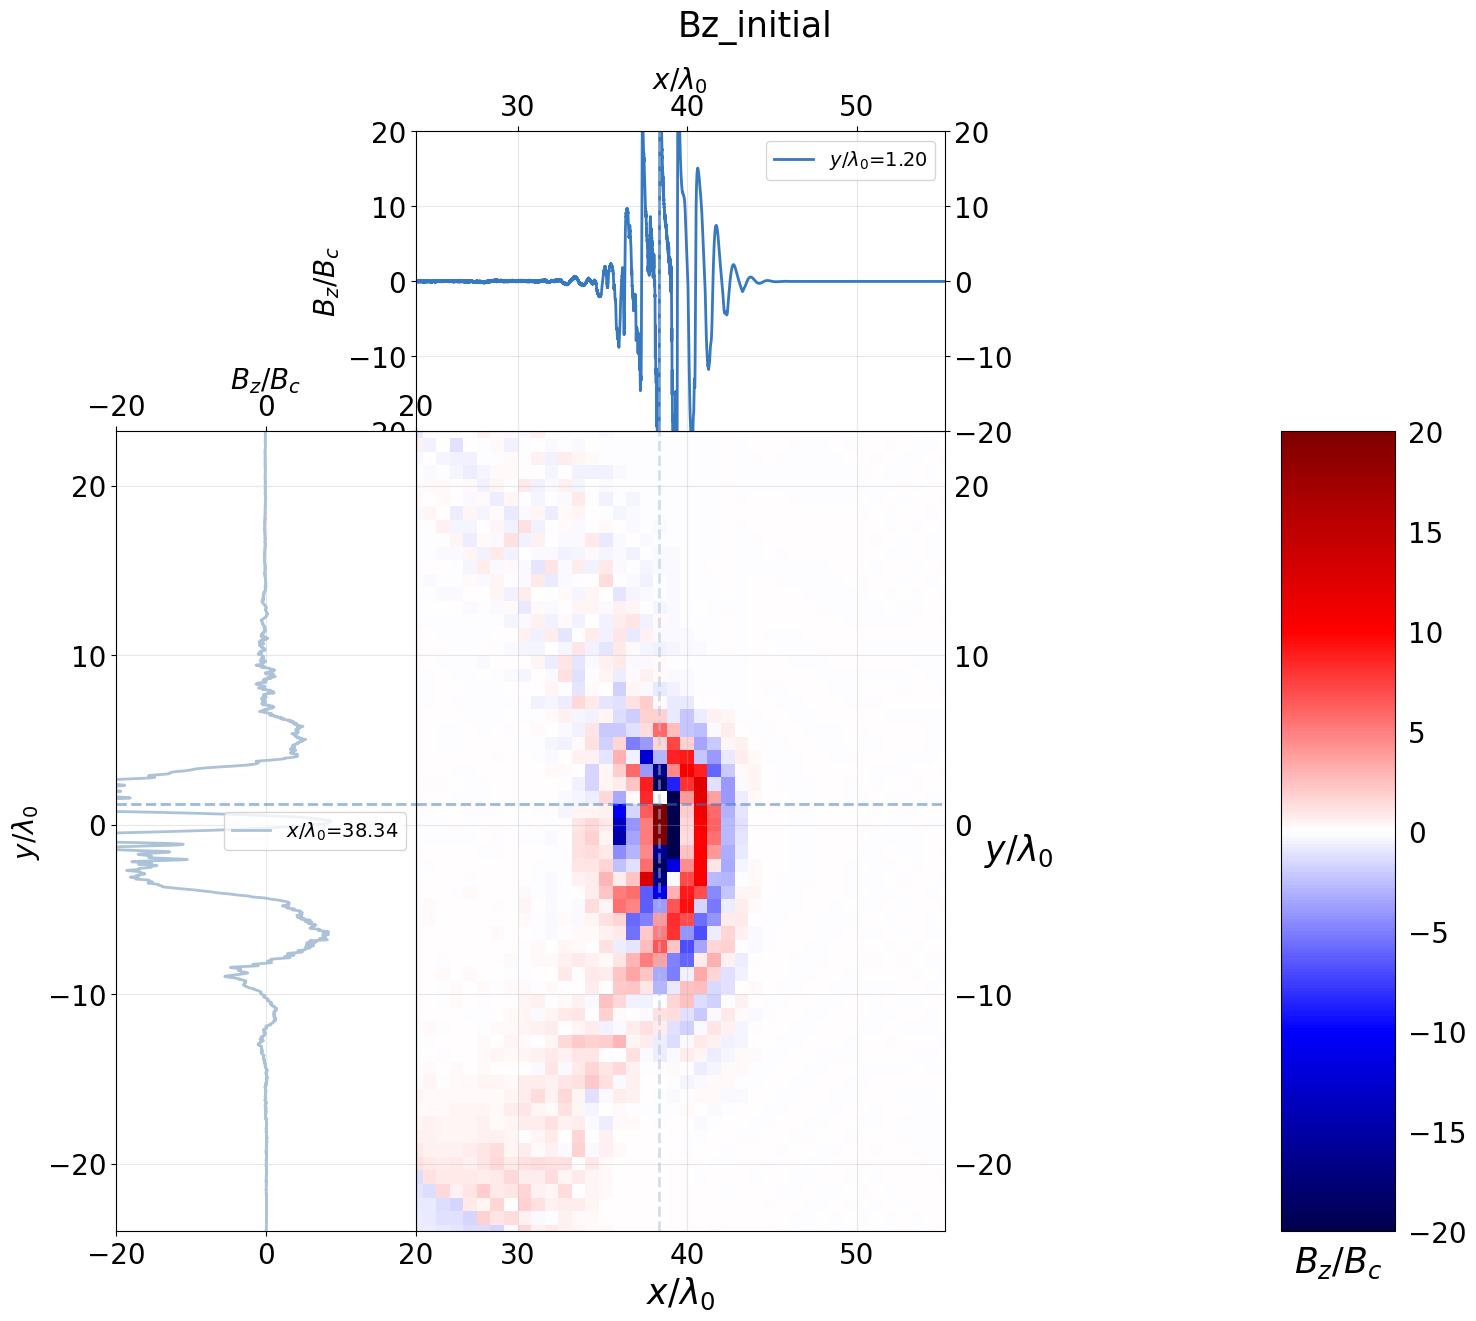

In [7]:
plot_2D_field(
    field        = Bz0 / laser_Bc,
    x_coordinate = x_coord / laser_lambda,
    y_coordinate = y_coord / laser_lambda,
    vmin=-laser_a0, vmax=laser_a0,
    label=r'$B_z / B_c$',
    xlabel=r'$x / \lambda_0$',
    ylabel=r'$y / \lambda_0$',
    step_x=200, step_y=200,
    return_fig=True,
    name='Bz_initial',
    working_dir=working_dir,
)
#print(f'Saved: {working_dir}/Bz_initial.png')

## 3. Define a mask and smooth its edges

Edit the mask expression below to select any region of interest.  
`smooth_mask` applies a raised-cosine (Tukey) taper over `mask_edge_length` cells at every mask boundary, so the field transitions smoothly to zero rather than being hard-cut.

figure size= [15.83288881 14.        ] inch
ax_main position= Bbox(x0=0.28421850570900653, y0=0.10714285714285714, x1=0.6210419923879913, y1=0.6785714285714285)


{'fig': <Figure size 1583.29x1400 with 5 Axes>,
 'ax_main': <Axes: xlabel='$x / \\lambda_0$', ylabel='$y / \\lambda_0$'>,
 'ax_panel_top': <Axes: xlabel='$x / \\lambda_0$', ylabel='mask weight'>,
 'ax_panel_left': <Axes: xlabel='mask weight', ylabel='$y / \\lambda_0$'>,
 'ax_cbar': <Axes: >,
 'ax_cbar_divider': <mpl_toolkits.axes_grid1.axes_divider.AxesDivider at 0x14b6cc168cd0>}

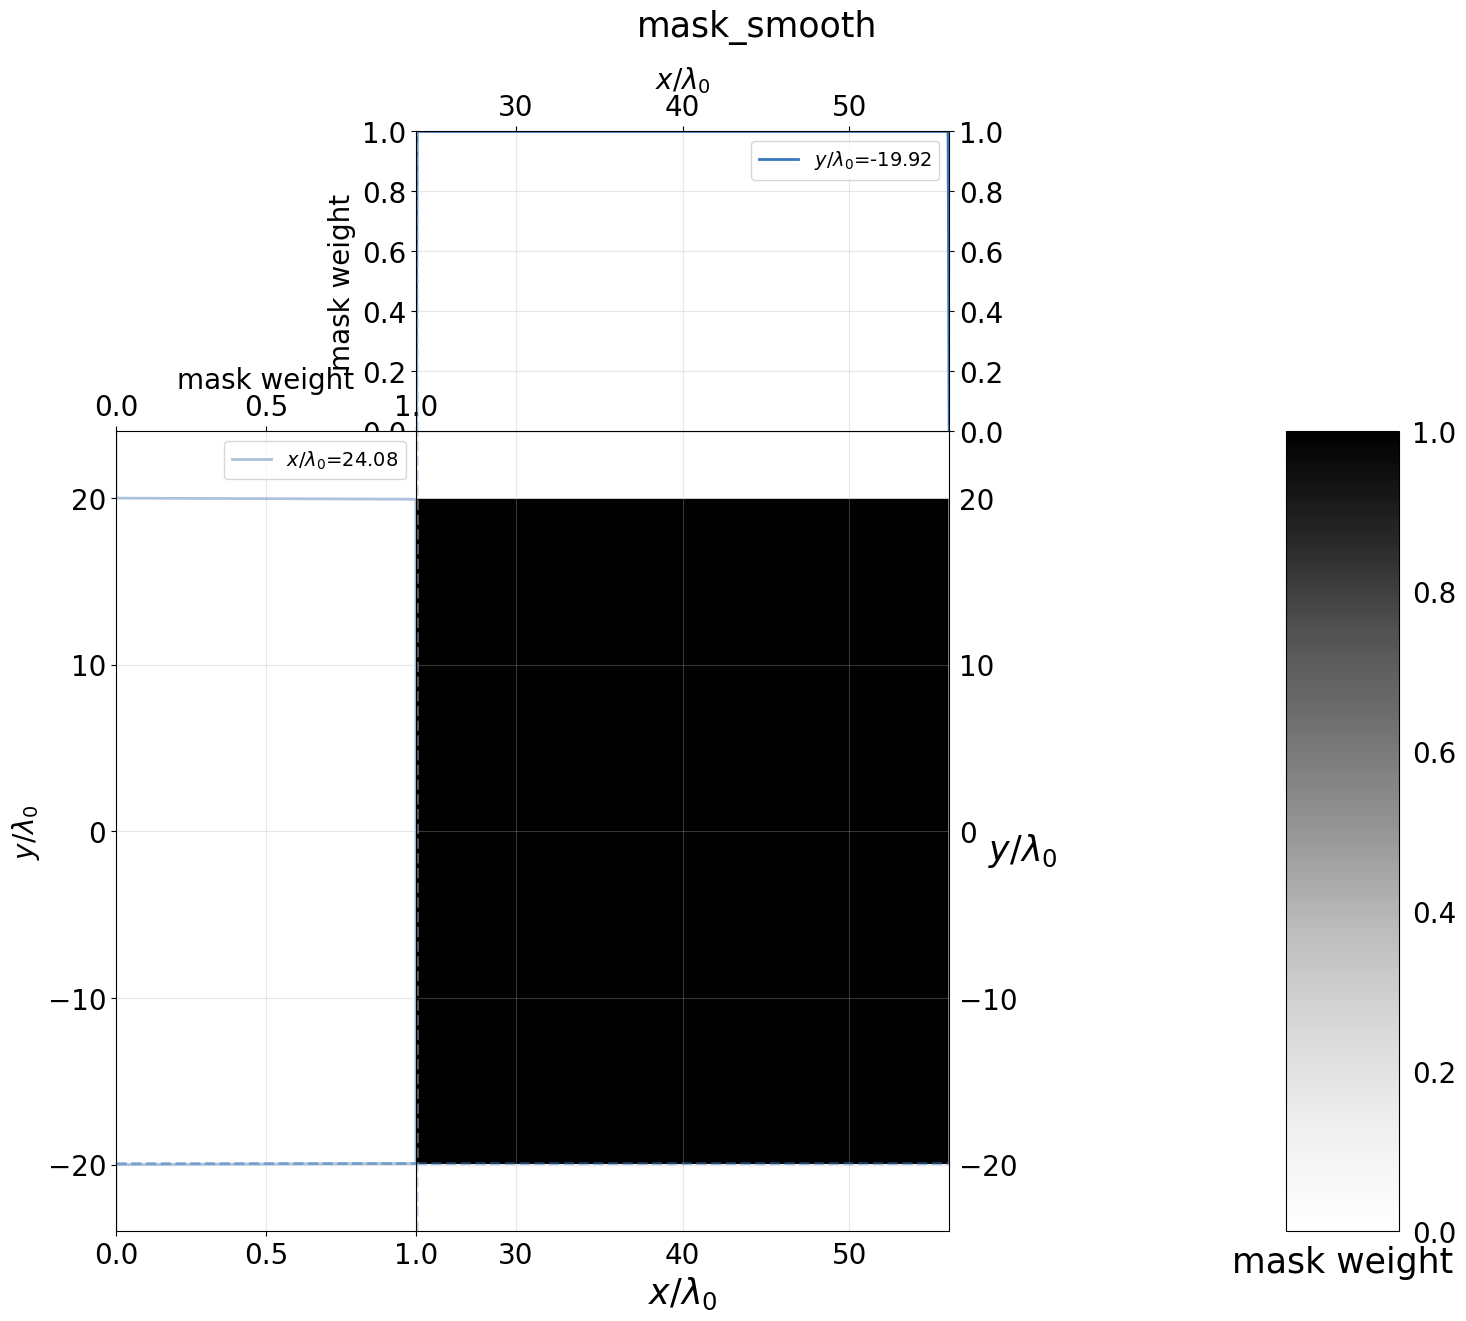

In [8]:
# ── build an arbitrary boolean mask ──────────────────────────────────────────
# meshgrid for convenience: xx[i,j] = x_coord[i], yy[i,j] = y_coord[j]
xx, yy = np.meshgrid(x_coord, y_coord, indexing='ij')   # shape (Nx, Ny)

# Example: rectangular box in physical coordinates
x_min_mask =  x_coord[0]   # ← adjust
x_max_mask =  x_coord[-1]  # ← adjust
y_min_mask = -20 * laser_lambda
y_max_mask =  20 * laser_lambda

mask_bool = (
    (xx >= x_min_mask) & (xx <= x_max_mask) &
    (yy >= y_min_mask) & (yy <= y_max_mask)
)   # shape (Nx, Ny), dtype bool

# Example alternative: circular mask
# cx, cy = 0.0, 0.0
# radius  = 15 * laser_lambda
# mask_bool = ((xx - cx)**2 + (yy - cy)**2) < radius**2

# ── smooth mask edges ────────────────────────────────────────────────────────
mask_smooth = smooth_mask(
    mask        = jnp.array(mask_bool, dtype=jnp.float64),
    edge_length = mask_edge_length,
)   # shape (Nx, Ny), float64, values in [0, 1]
mask_smooth = np.array(mask_smooth)

# ── visualize mask ────────────────────────────────────────────────────────────
plot_2D_field(
    field        = mask_smooth,
    x_coordinate = x_coord / laser_lambda,
    y_coordinate = y_coord / laser_lambda,
    vmin=0.0, vmax=1.0,
    cmap='Grays',
    label='mask weight',
    xlabel=r'$x / \lambda_0$',
    ylabel=r'$y / \lambda_0$',
    step_x=2, step_y=2,
    return_fig=True,
    name='mask_smooth',
    working_dir=working_dir,
)
#print(f'Saved: {working_dir}/mask_smooth.png')

## 4. Apply mask and initialize the solver

In [6]:
# Apply smoothed mask to initial fields
Ex0_masked = Ex0# * mask_smooth   # shape (Nx, Ny)
Ey0_masked = Ey0# * mask_smooth
Bz0_masked = Bz0# * mask_smooth

# Build zero arrays for the missing components (2D TM mode: Bx=By=0, Ez=0)
zeros = np.zeros_like(Ex0_masked)

solver = Spectral_Maxwell_Solver_2D(
    E0x = Ex0_masked[::4,::4],
    E0y = Ey0_masked[::4,::4],
    E0z = zeros[::4,::4],
    B0x = zeros[::4,::4],
    B0y = zeros[::4,::4],
    B0z = Bz0_masked[::4,::4],
    x_coordinate = x_coord[::4],
    y_coordinate = y_coord[::4],
)
print('Solver initialized.')

Stacked field shape: (3, 2000, 3000, 1)
Stacked field shape: (3, 2000, 3000, 1)
Initial field shapes (3, 2000, 3000, 1) verified.
Initial field shapes (3, 2000, 3000, 1) verified.
Max relative divergence error: L*|∇·F|/|F| = 3.03e+00
Max relative divergence error: L*|∇·F|/|F| = 0.00e+00
Initial Field divergence check passed: relative L*|∇·F|/|F| = 0.0 <= 0.5
Pad widths for each axis: [(0, 0), (0, 0), (1008, 1008), (1508, 1508), (0, 0)]
Input shape: (2, 3, 2000, 3000, 1)
Output padded shape: (2, 3, 4016, 6016, 1)


╭──────── Initial spectrum from field ────────╮
│ shape: (2, 3, 4016, 6016, 1)                │
│ dtype: complex128                           │
│ size: 2.2 GiB                               │
│ NamedSharding: P('EM', 'channel')           │
│ axis 0 is sharded: CPU 0 contains 0:1 (1/2) │
│                    Total size: 2            │
│ axis 1 is sharded: CPU 0 contains 0:1 (1/3) │
│                    Total size: 3            │
╰─────────────────────────────────────────────╯

Padded field shapes (2, 3, 4016, 6016, 1) verified.
k-space grid shapes (3, 4016, 6016, 1) verified.
Transversality enforced in k-space.
Solver initialized.


## 5. Propagate and plot

`window_shift_velocity=(0.0, 0.0)` keeps the coordinate window fixed.  
Set `window_shift_velocity=(C.speed_of_light, 0.0)` if you want to follow the pulse.

Evolution time: 1.8679589331096515e-13 s, window shift velocity: [2.99792458e+08 0.00000000e+00 0.00000000e+00] m/s
figure size= [15.81543624 14.        ] inch
ax_main position= Bbox(x0=0.28453214513049013, y0=0.10714285714285714, x1=0.6206238064926798, y1=0.6785714285714285)
figure size= [15.81543624 14.        ] inch
ax_main position= Bbox(x0=0.28453214513049013, y0=0.10714285714285714, x1=0.6206238064926798, y1=0.6785714285714285)
[01/11] t=+70.00 T0  |Ex|_max=5.099 Ec  |Bz|_max=50.670 Bc

All PNGs saved to: /scratch/gpfs/MIKHAILOVA/zl8336/Curved_surface/a0=20/2D/K=-0.005,D=0.02,L=0.00


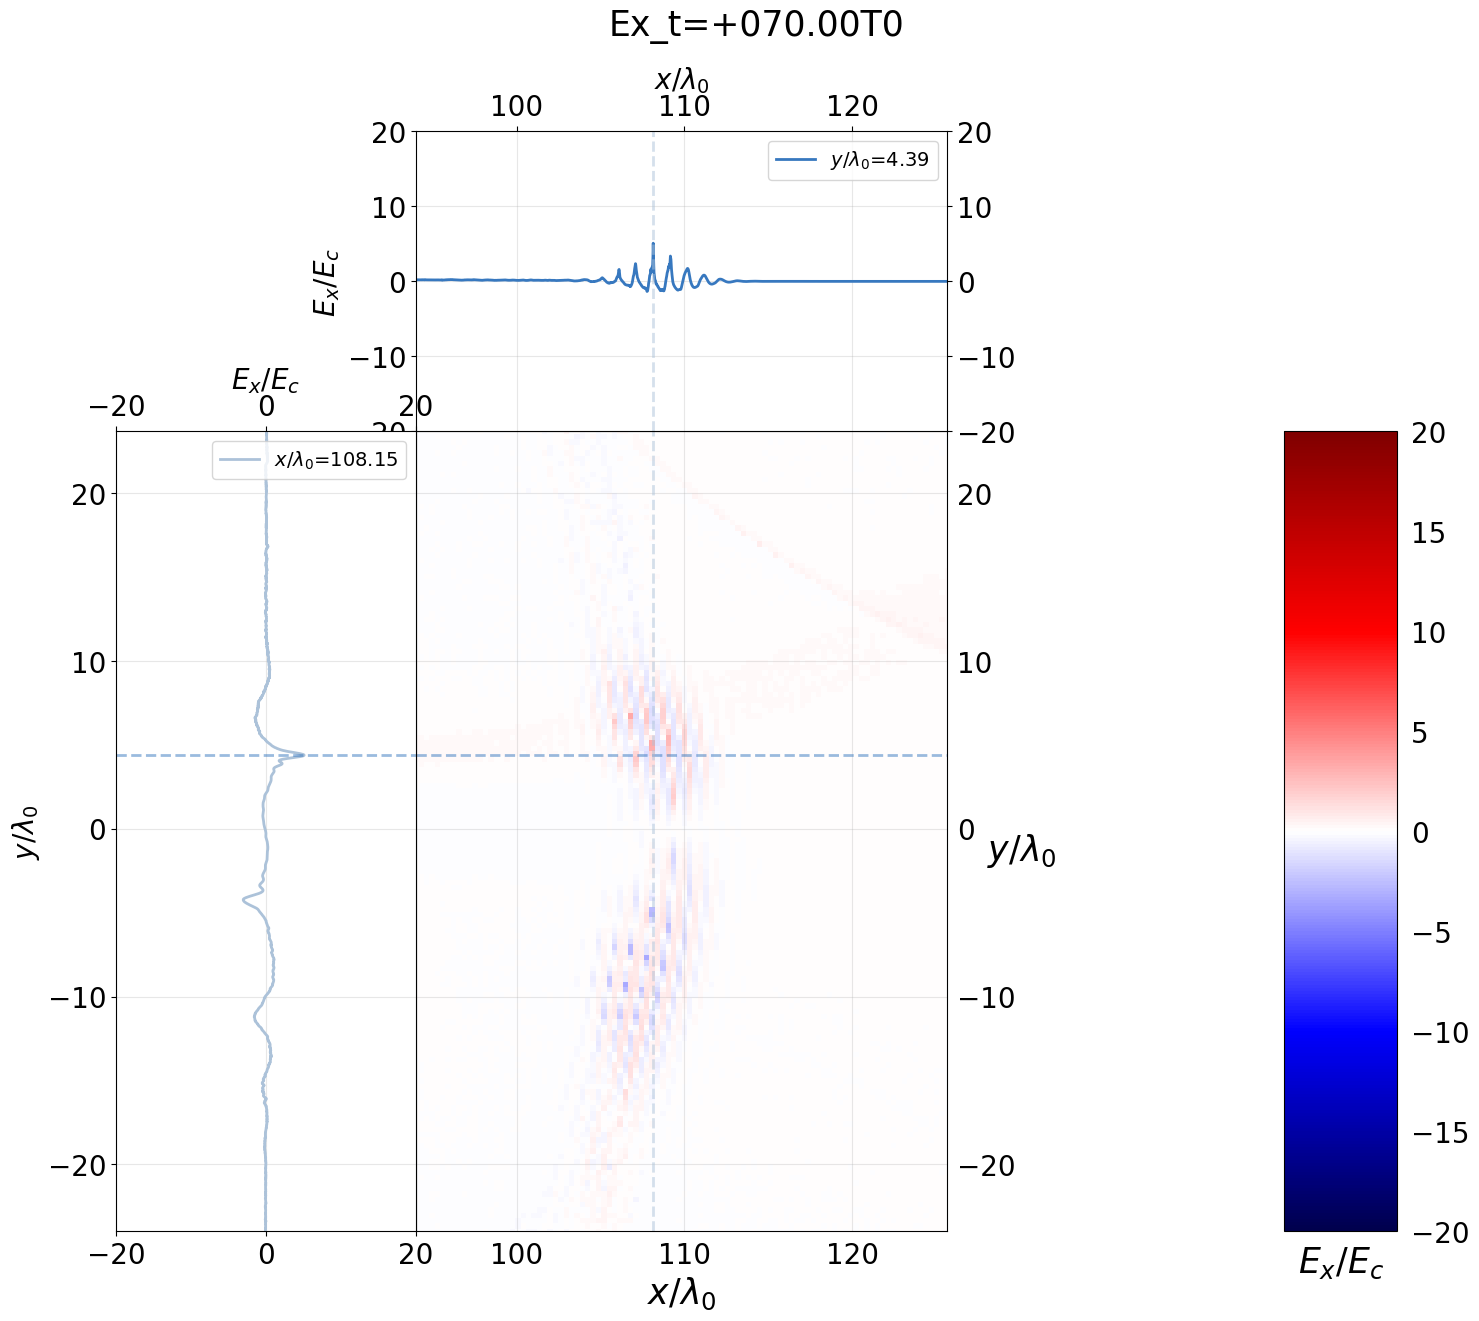

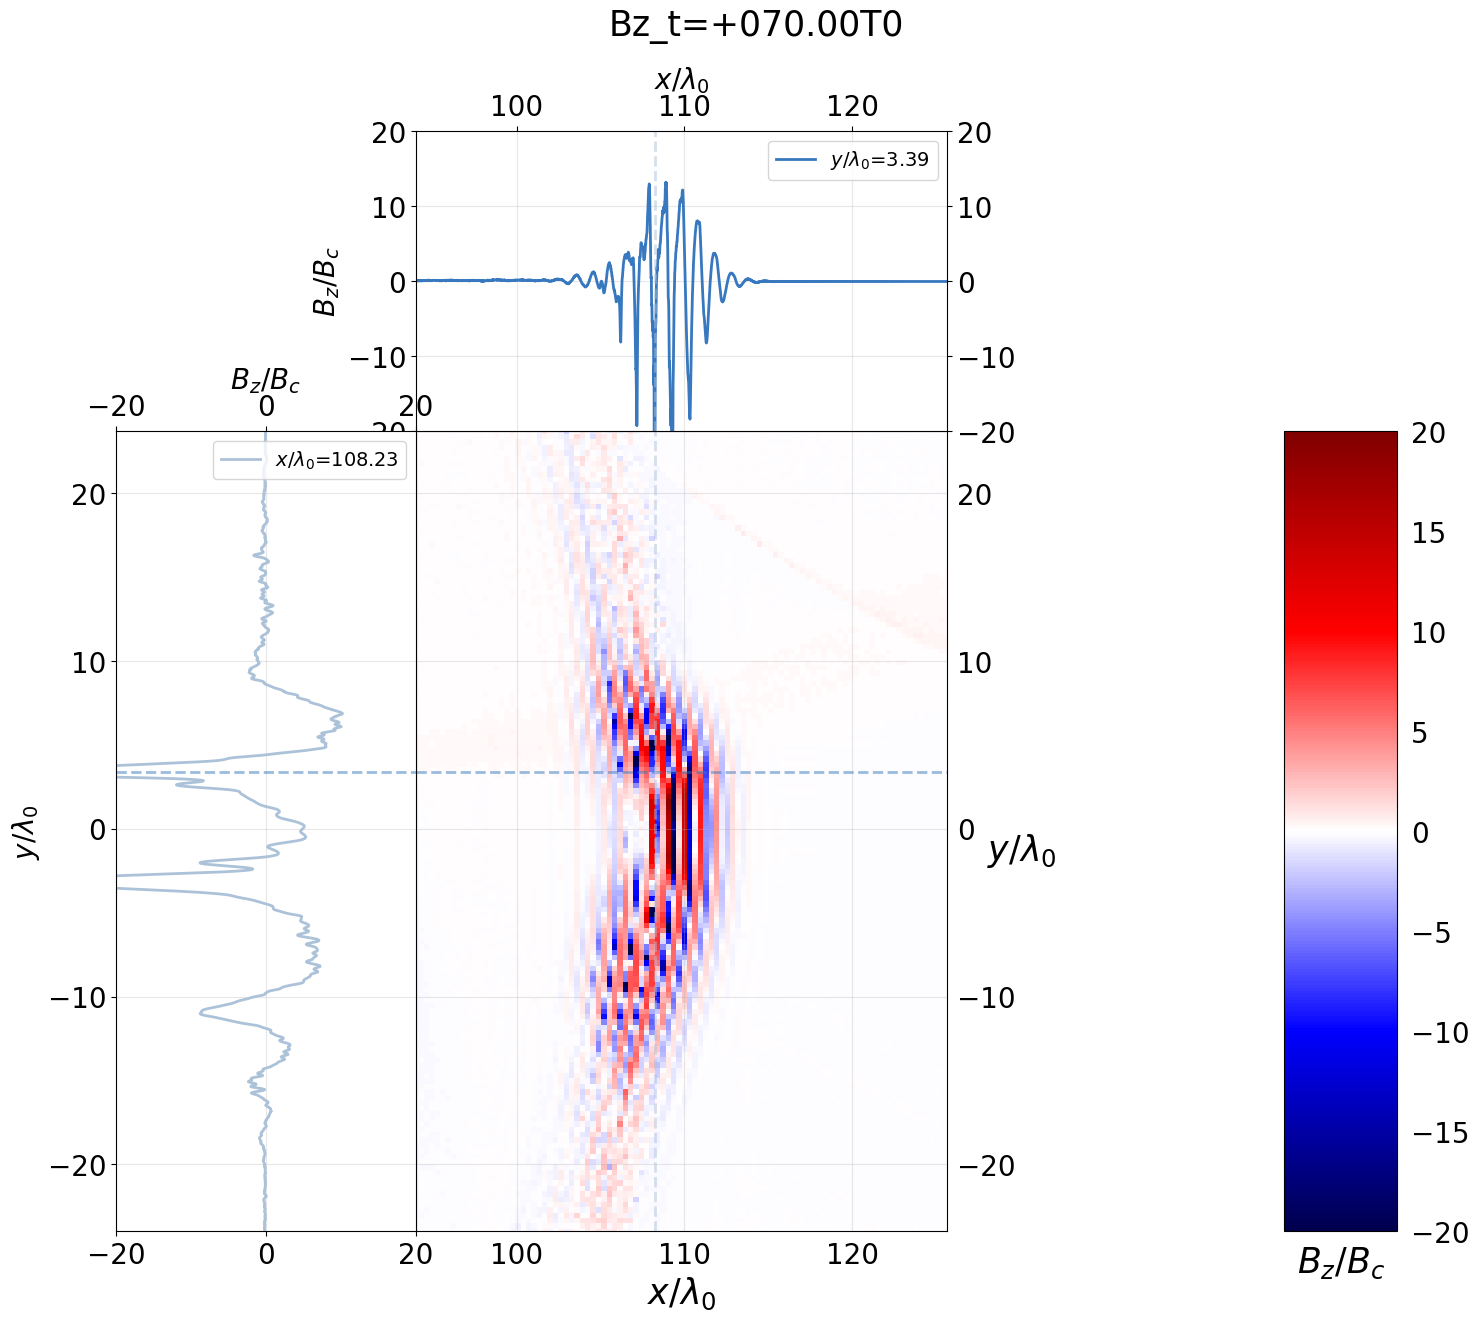

In [13]:
times = np.linspace(t_start, t_end, n_steps)
times=[70 * laser_period]
for step_idx, t in enumerate(times):
    result = solver.evolution(
        evolution_time        = float(t),
        window_shift_velocity = (C.speed_of_light, 0.0),   # fixed window; change to (c, 0) to follow pulse
    )

    Ex  = np.array(result['Ex'])              # shape (Nx, Ny)
    Bz  = np.array(result['Bz'])              # shape (Nx, Ny)
    x_c = np.array(result['x_coordinate'])    # (Nx,)
    y_c = np.array(result['y_coordinate'])    # (Ny,)

    tag = f't={t/laser_period:+07.2f}T0'


    
    # ── plot Ex ──────────────────────────────────────────────────────────────
    plot_2D_field(
        field        = Ex / laser_Ec,
        x_coordinate = x_c / laser_lambda,
        y_coordinate = y_c / laser_lambda,
        vmin=-laser_a0, vmax=laser_a0,
        label=r'$E_x / E_c$',
        xlabel=r'$x / \lambda_0$',
        ylabel=r'$y / \lambda_0$',
        step_x=20, step_y=20,
        return_fig=True,
        name=f'Ex_{tag}',
        working_dir=working_dir,
    )

    

    # ── plot Bz ──────────────────────────────────────────────────────────────
    plot_2D_field(
        field        = Bz / laser_Bc,
        x_coordinate = x_c / laser_lambda,
        y_coordinate = y_c / laser_lambda,
        vmin=-laser_a0, vmax=laser_a0,
        label=r'$B_z / B_c$',
        xlabel=r'$x / \lambda_0$',
        ylabel=r'$y / \lambda_0$',
        step_x=20, step_y=20,
        return_fig=True,
        name=f'Bz_{tag}',
        working_dir=working_dir,
    )

    print(f'[{step_idx+1:02d}/{n_steps}] t={t/laser_period:+.2f} T0  '
          f'|Ex|_max={np.max(np.abs(Ex))/laser_Ec:.3f} Ec  '
          f'|Bz|_max={np.max(np.abs(Bz))/laser_Bc:.3f} Bc')

print(f'\nAll PNGs saved to: {working_dir}')

## Optional: inline display of the last frame

In [ ]:
import matplotlib
matplotlib.use('inline')    # switch to inline for display in notebook
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, field_arr, label, norm in [
    (axes[0], Ex, r'$E_x / E_c$',  laser_Ec),
    (axes[1], Bz, r'$B_z / B_c$',  laser_Bc),
]:
    im = ax.pcolormesh(
        y_c / laser_lambda, x_c / laser_lambda,
        field_arr / norm,
        cmap='seismic', vmin=-laser_a0, vmax=laser_a0,
    )
    ax.set_xlabel(r'$y / \lambda_0$')
    ax.set_ylabel(r'$x / \lambda_0$')
    ax.set_title(label + f'  t={times[-1]/laser_period:+.2f} T0')
    plt.colorbar(im, ax=ax, label=label)

fig.tight_layout()
plt.show()